# MaxFormer SNN Reproducibility — Report Figures

Generates all figures for the DPDL reproducibility report on *Spiking Neural Networks Need High-Frequency Information* (NeurIPS 2025).

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# ── Output directories (one figures/ subfolder per experiment) ───────────────
IRIDIS = Path('iridis_results')

OUT_AVG_VS_MAX = IRIDIS / 'AvgVsMax'    / 'figures'
OUT_FULL_MAX   = IRIDIS / 'FullMax_c100' / 'figures'
OUT_BETA       = IRIDIS / 'Beta_Sweep'   / 'figures'
OUT_OPERATORS  = IRIDIS / 'Operators'    / 'figures'

for _d in [OUT_AVG_VS_MAX, OUT_FULL_MAX, OUT_BETA, OUT_OPERATORS]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_csv(rel_path):
    """Load a CSV relative to the repo root (parent of this notebook)."""
    return pd.read_csv(Path(rel_path))

def best_top1(df, col='eval_top1'):
    """Return (best_value, epoch_at_best) from a summary DataFrame."""
    idx = df[col].idxmax()
    return float(df.loc[idx, col]), int(df.loc[idx, 'epoch'])

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 100,
})
SAVE_DPI = 150

# ── Colour palette ────────────────────────────────────────────────────────────
C = {
    'AvgFormer':        '#4C72B0',
    'MaxFormer-lite':   '#DD8452',
    'Full-MaxFormer':   '#2ca02c',
    'ANN-Avg':          '#55A868',
    'ANN-Max':          '#C44E52',
}

print('Setup complete. Output directories:')
for _d in [OUT_AVG_VS_MAX, OUT_FULL_MAX, OUT_BETA, OUT_OPERATORS]:
    print(f'  {_d}')

Setup complete. Output directories:
  iridis_results\AvgVsMax\figures
  iridis_results\FullMax_c100\figures
  iridis_results\Beta_Sweep\figures
  iridis_results\Operators\figures


## 2.1 — Learning Curves

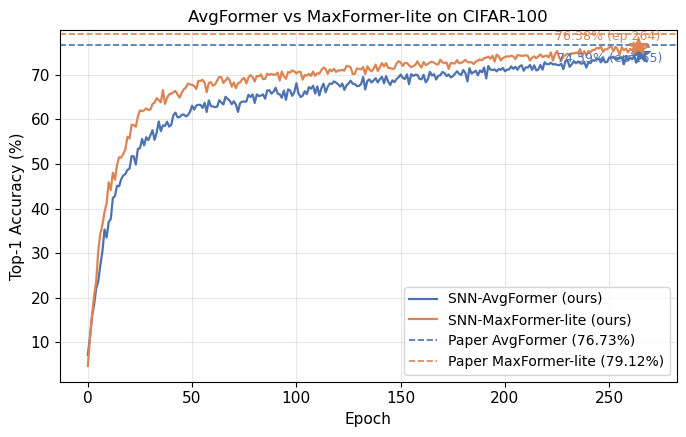

Best SNN-Avg: 74.59% @ ep 265
Best SNN-Max: 76.38% @ ep 264


In [16]:
df_avg = load_csv('iridis_results/AvgVsMax/avg/AvgVsMax_avg/summary.csv')
df_max = load_csv('iridis_results/AvgVsMax/max/AvgVsMax_max/summary.csv')

best_avg, ep_avg = best_top1(df_avg)
best_max, ep_max = best_top1(df_max)

PAPER_AVG = 76.73
PAPER_MAX = 79.12

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(df_avg['epoch'], df_avg['eval_top1'],
        color=C['AvgFormer'], lw=1.6, label='SNN-AvgFormer (ours)')
ax.plot(df_max['epoch'], df_max['eval_top1'],
        color=C['MaxFormer-lite'], lw=1.6, label='SNN-MaxFormer-lite (ours)')

ax.scatter([ep_avg], [best_avg], marker='*', s=180,
           color=C['AvgFormer'], zorder=5)
ax.scatter([ep_max], [best_max], marker='*', s=180,
           color=C['MaxFormer-lite'], zorder=5)

ax.axhline(PAPER_AVG, color=C['AvgFormer'], lw=1.2, ls='--',
           label=f'Paper AvgFormer ({PAPER_AVG:.2f}%)')
ax.axhline(PAPER_MAX, color=C['MaxFormer-lite'], lw=1.2, ls='--',
           label=f'Paper MaxFormer-lite ({PAPER_MAX:.2f}%)')

ax.annotate(f'{best_avg:.2f}% (ep {ep_avg})',
            xy=(ep_avg, best_avg), xytext=(ep_avg - 40, best_avg - 1.8),
            fontsize=9, color=C['AvgFormer'],
            arrowprops=dict(arrowstyle='->', color=C['AvgFormer'], lw=0.9))
ax.annotate(f'{best_max:.2f}% (ep {ep_max})',
            xy=(ep_max, best_max), xytext=(ep_max - 40, best_max + 1.5),
            fontsize=9, color=C['MaxFormer-lite'],
            arrowprops=dict(arrowstyle='->', color=C['MaxFormer-lite'], lw=0.9))

ax.set_xlabel('Epoch')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('AvgFormer vs MaxFormer-lite on CIFAR-100')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_AVG_VS_MAX / 'learning_curves.png', dpi=SAVE_DPI)
plt.show()
print(f'Best SNN-Avg: {best_avg:.2f}% @ ep {ep_avg}')
print(f'Best SNN-Max: {best_max:.2f}% @ ep {ep_max}')

## 2.1 — Accuracy Bar Chart

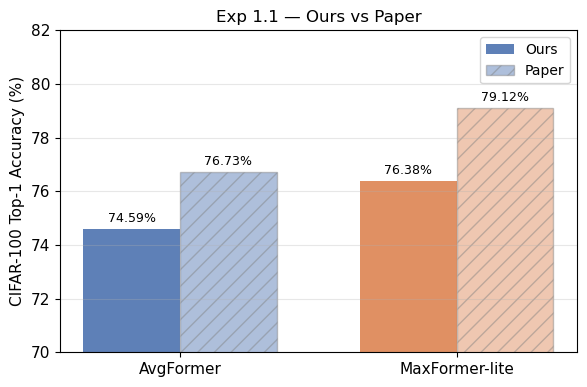

In [17]:
models = ['AvgFormer', 'MaxFormer-lite']
ours   = [best_avg, best_max]
paper  = [PAPER_AVG, PAPER_MAX]

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_ours  = ax.bar(x - w/2, ours,  w, label='Ours',  color=[C['AvgFormer'], C['MaxFormer-lite']], alpha=0.9)
bars_paper = ax.bar(x + w/2, paper, w, label='Paper', color=[C['AvgFormer'], C['MaxFormer-lite']], alpha=0.45,
                    hatch='//', edgecolor='grey')

for bar, val in zip(bars_ours, ours):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_paper, paper):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('CIFAR-100 Top-1 Accuracy (%)')
ax.set_title('Exp 1.1 — Ours vs Paper')
ax.set_ylim(70, 82)
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_AVG_VS_MAX / 'accuracy_bar.png', dpi=SAVE_DPI)
plt.show()

## 2.2 — Full MaxFormer Combined

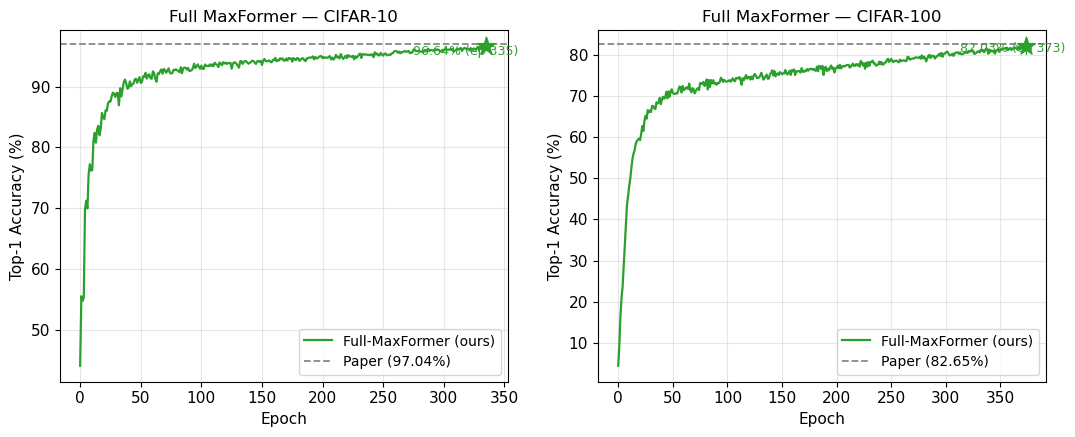

CIFAR-10:  96.64% @ ep 335  (paper 97.04%)
CIFAR-100: 82.03% @ ep 373 (paper 82.65%)


In [18]:
df_c10  = load_csv('iridis_results/FullMax_c10/FullMax_c10/summary.csv')
df_c100 = load_csv('iridis_results/FullMax_c100/FullMax_c100/summary.csv')

best_c10,  ep_c10  = best_top1(df_c10)
best_c100, ep_c100 = best_top1(df_c100)

PAPER_C10  = 97.04
PAPER_C100 = 82.65

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, df, best, ep, paper_t, dataset in [
        (axes[0], df_c10,  best_c10,  ep_c10,  PAPER_C10,  'CIFAR-10'),
        (axes[1], df_c100, best_c100, ep_c100, PAPER_C100, 'CIFAR-100')]:
    ax.plot(df['epoch'], df['eval_top1'],
            color=C['Full-MaxFormer'], lw=1.6, label='Full-MaxFormer (ours)')
    ax.scatter([ep], [best], marker='*', s=180, color=C['Full-MaxFormer'], zorder=5)
    ax.axhline(paper_t, color='#888888', lw=1.3, ls='--',
               label=f'Paper ({paper_t:.2f}%)')
    ax.annotate(f'{best:.2f}% (ep {ep})',
                xy=(ep, best), xytext=(ep - 60, best - 1.5),
                fontsize=9, color=C['Full-MaxFormer'],
                arrowprops=dict(arrowstyle='->', color=C['Full-MaxFormer'], lw=0.8))
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title(f'Full MaxFormer — {dataset}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_FULL_MAX / 'learning_curves.png', dpi=SAVE_DPI)
plt.show()
print(f'CIFAR-10:  {best_c10:.2f}% @ ep {ep_c10}  (paper {PAPER_C10}%)')
print(f'CIFAR-100: {best_c100:.2f}% @ ep {ep_c100} (paper {PAPER_C100}%)')

## 2.5 — Beta Sweep Log Parser

In [19]:
# Pattern: lines that end a test epoch (batch N/N) and carry Acc@1
_RE_TEST = re.compile(
    r'Test:\s+\[\s*(\d+)/(\d+)\].*Acc@1:\s+[\d.]+\s+\(([\d.]+)\)'
)

def parse_log_epochs(path):
    """Return list of per-epoch mean top-1 accuracy floats from an Iridis log.

    Each epoch-final line appears twice in the SLURM log:
      - once with    'INFO:train:Test: [N/N] ...'
      - once without              'Test: [N/N] ...'
    We skip the INFO: prefixed duplicates to avoid double-counting.
    """
    accuracies = []
    with open(path, 'r', errors='replace') as fh:
        for line in fh:
            # Skip INFO:... duplicate lines (same content already in plain line)
            if line.startswith('INFO:'):
                continue
            m = _RE_TEST.search(line)
            if m:
                batch_idx, total, acc = m.group(1), m.group(2), m.group(3)
                # Keep only the final batch of each epoch (N/N)
                if batch_idx == total:
                    accuracies.append(float(acc))
    return accuracies

beta_logs = {
    0.20: 'iridis_results/Beta_Sweep/logs/exp3_2_b02_920567.out',
    0.50: 'iridis_results/Beta_Sweep/logs/exp3_2_b05_920568.out',
    0.75: 'iridis_results/Beta_Sweep/logs/exp3_2_b075_920569.out',
    0.90: 'iridis_results/Beta_Sweep/logs/exp3_2_b09_920570.out',
}
tau_map = {0.20: 1.25, 0.50: 2.00, 0.75: 4.00, 0.90: 10.0}

beta_curves = {}
for beta, log_path in beta_logs.items():
    epochs = parse_log_epochs(log_path)
    beta_curves[beta] = epochs
    best = max(epochs) if epochs else float('nan')
    print(f'beta={beta:.2f}  tau={tau_map[beta]:.2f}  '
          f'epochs_parsed={len(epochs):3d}  best={best:.2f}%')

beta=0.20  tau=1.25  epochs_parsed=177  best=78.02%
beta=0.50  tau=2.00  epochs_parsed=179  best=78.86%
beta=0.75  tau=4.00  epochs_parsed=176  best=77.72%
beta=0.90  tau=10.00  epochs_parsed=174  best=73.53%


## 2.5 — Beta Accuracy Bar

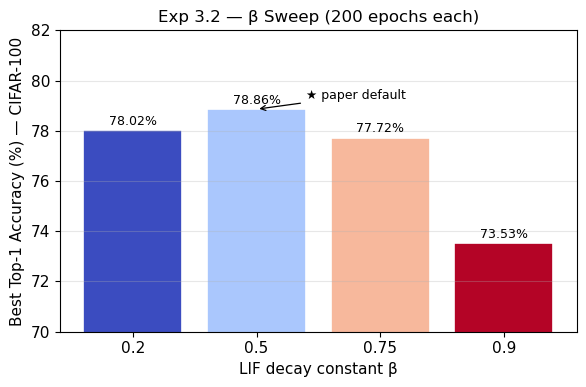

In [20]:
betas = [0.20, 0.50, 0.75, 0.90]
best_accs = [max(beta_curves[b]) if beta_curves[b] else float('nan') for b in betas]

cmap = plt.cm.coolwarm
norm = matplotlib.colors.Normalize(vmin=0, vmax=len(betas) - 1)
bar_colors = [cmap(norm(i)) for i in range(len(betas))]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(b) for b in betas], best_accs, color=bar_colors, edgecolor='white', lw=1.2)

default_idx = betas.index(0.50)
ax.annotate('★ paper default',
            xy=(default_idx, best_accs[default_idx]),
            xytext=(default_idx + 0.4, best_accs[default_idx] + 0.4),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.9))

for bar, val in zip(bars, best_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('LIF decay constant β')
ax.set_ylabel('Best Top-1 Accuracy (%) — CIFAR-100')
ax.set_title('Exp 3.2 — β Sweep (200 epochs each)')
ax.set_ylim(70, 82)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_BETA / 'beta_bar.png', dpi=SAVE_DPI)
plt.show()

## 2.5 — Beta Learning Curves

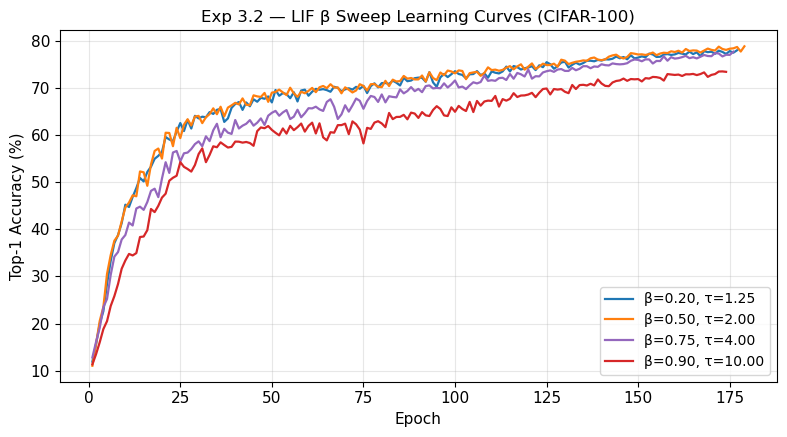

In [21]:
beta_colors = {
    0.20: '#1f77b4',
    0.50: '#ff7f0e',
    0.75: '#9467bd',
    0.90: '#d62728',
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for beta, epochs in sorted(beta_curves.items()):
    if not epochs:
        continue
    ax.plot(range(1, len(epochs) + 1), epochs,
            color=beta_colors[beta], lw=1.6,
            label=f'β={beta:.2f}, τ={tau_map[beta]:.2f}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Exp 3.2 — LIF β Sweep Learning Curves (CIFAR-100)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_BETA / 'beta_curves.png', dpi=SAVE_DPI)
plt.show()

## 3.2 — Alternative Operators

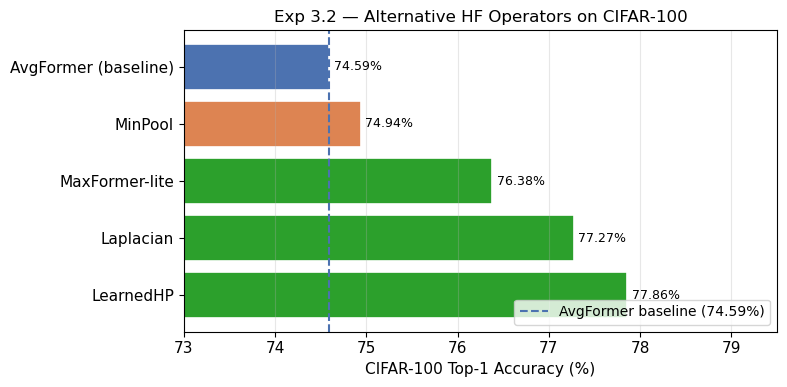

In [22]:
operator_results = {
    'AvgFormer (baseline)': 74.59,
    'MaxFormer-lite':       76.38,
    'MinPool':              74.94,
    'Laplacian':            77.27,
    'LearnedHP':            77.86,
}
AVG_BASE = 74.59

sorted_ops = sorted(operator_results.items(), key=lambda x: x[1], reverse=True)
names, accs = zip(*sorted_ops)

bar_cols = ['#2ca02c' if a > AVG_BASE + 1 else '#DD8452' if a > AVG_BASE else '#4C72B0'
            for a in accs]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(names)), accs, color=bar_cols, edgecolor='white', lw=1.2)
ax.axvline(AVG_BASE, color='#4C72B0', lw=1.5, ls='--', label=f'AvgFormer baseline ({AVG_BASE}%)')

for i, (bar, val) in enumerate(zip(bars, accs)):
    ax.text(val + 0.05, i, f'{val:.2f}%', va='center', fontsize=9)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('CIFAR-100 Top-1 Accuracy (%)')
ax.set_title('Exp 3.2 — Alternative HF Operators on CIFAR-100')
ax.set_xlim(73, 79.5)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_OPERATORS / 'operators_bar.png', dpi=SAVE_DPI)
plt.show()